Student_Placement_Salary_Prediction.ipynb

In [68]:
import pandas as pd

df = pd.read_csv("student_placement_salary_elite_v2.csv")
df.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


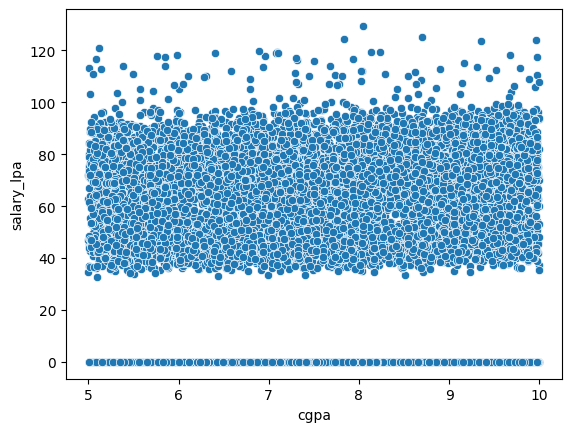

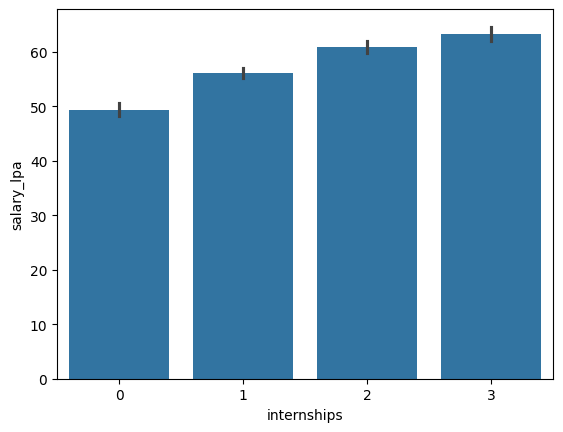

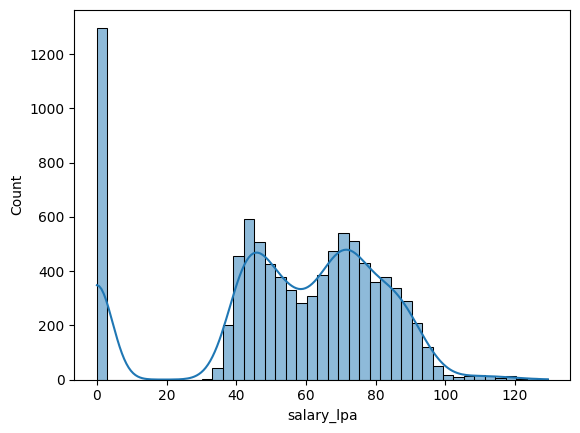

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='cgpa', y='salary_lpa', data=df)
plt.show()

sns.barplot(x='internships', y='salary_lpa', data=df)
plt.show()

sns.histplot(df['salary_lpa'], kde=True)
plt.show()

In [70]:
df['total_skills'] = (
    df['python_skill'] +
    df['dsa_skill'] +
    df['ml_skill'] +
    df['web_dev_skill']
)

In [71]:
df.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,...,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa,total_skills
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,...,1,3,0,62.6,2,1,MNC,Software Engineer,63.55,2
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,...,1,6,0,77.5,2,1,MNC,Data Scientist,75.17,2
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,...,0,5,1,76.0,3,1,MNC,Software Engineer,80.44,3
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,...,0,6,0,74.3,2,1,MNC,Software Engineer,72.11,2
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,...,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05,2


In [72]:
df = df.drop(columns=['job_role', 'company_type'], errors='ignore')

In [73]:
df.columns

Index(['student_id', 'cgpa', 'branch', 'college_tier', 'python_skill',
       'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score',
       'communication_score', 'aptitude_score', 'internships', 'projects',
       'backlogs', 'resume_score', 'skill_score', 'placed', 'salary_lpa',
       'total_skills'],
      dtype='object')

In [74]:
df = pd.get_dummies(df, drop_first=True)

In [75]:
df.head()

,cgpa,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,...,student_id_S995,student_id_S996,student_id_S997,student_id_S998,student_id_S999,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical
0,6.87,1,1,1,0,0,15.6,4.3,92.0,1,...,False,False,False,False,False,True,False,False,False,False
1,6.52,2,1,0,0,1,13.9,5.8,62.0,1,...,False,False,False,False,False,True,False,False,False,False
2,5.33,1,1,1,1,0,9.8,8.1,66.4,0,...,False,False,False,False,False,False,False,False,True,False
3,6.04,3,1,0,1,0,39.5,9.6,83.6,0,...,False,False,False,False,False,True,False,False,False,False
4,6.78,2,0,1,0,1,7.5,9.9,86.3,0,...,False,False,False,False,False,False,False,False,False,True


In [76]:
X = df.drop('salary_lpa', axis=1)
y = df['salary_lpa']

In [77]:
X.shape, y.shape

((9000, 9020), (9000,))

In [78]:
X = X.iloc[:, :100]   # keep only first 100 columns

In [79]:
X.shape

(9000, 100)

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [82]:
y_pred = model.predict(X_test)

In [83]:
y_pred[:5]

array([61.86828438, 71.03096494, 67.07016313, 48.92615714, 65.85562646])

In [84]:
import pandas as pd

pd.DataFrame({
    "Actual": y_test.values[:5],
    "Predicted": y_pred[:5]
})

,Actual,Predicted
0,66.71,61.868284
1,76.91,71.030965
2,76.19,67.070163
3,42.06,48.926157
4,82.42,65.855626


In [85]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 140.44390705933301
RMSE: 11.850903217026667
R2 Score: 0.8241390279850627


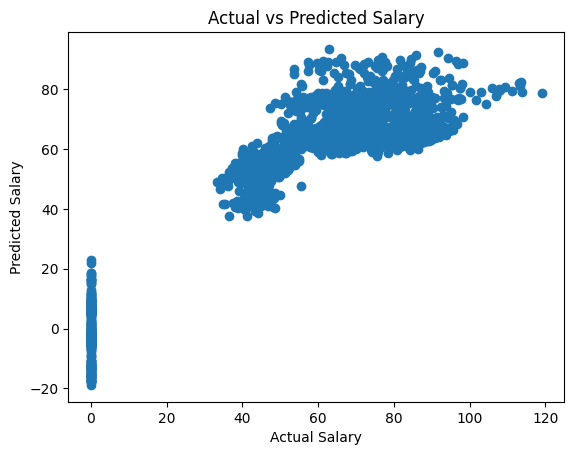

In [86]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

In [87]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=10)
rf.fit(X_train, y_train)

print("Random Forest R2:", r2_score(y_test, rf.predict(X_test)))

Random Forest R2: 0.8871370376338132


## Conclusion

- Linear Regression achieved R² score of 0.82
- Random Forest performed better with R² score of  0.88
- Skills, internships, and CGPA significantly impact salary
- The model can reasonably predict student salaries

Hence, Random Forest is the best model for this dataset.